<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Lab 6: Association Rule Mining with Apriori and FP-Growth with Online Retail UIC data</span><br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import time

## 1. Data Preparation 

In [2]:
# Load and clean
df = pd.read_excel('./data/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Data Quality Audit (Before Cleaning)

It is visible that the data has product names as showin in the description colomun. And the following details are assessed next as part of the data preprocessing
- Missing values in key fields
- Canceled transactions (InvoiceNo starts with 'C')
- Fully duplicated rows
- Non-positive quantities (Quantity ≤ 0)
- These checks help us understand the amount and type of noise present in the dataset.

In [3]:
# Total rows
total_rows = len(df)

# 1. Null value count
null_counts = df[['InvoiceNo', 'Description', 'CustomerID']].isnull().sum()

# 2. Canceled transactions
canceled_orders = df['InvoiceNo'].astype(str).str.startswith('C').sum()

# 3. Exact duplicate rows
duplicate_rows = df.duplicated().sum()

# 4. Negative or zero quantities
non_positive_qty = (df['Quantity'] <= 0).sum()

# Print results
print(f"🔢 Total rows: {total_rows}")
print("🧼 Null counts:")
print(null_counts)
print(f"⚠️ Canceled orders (InvoiceNo starts with 'C'): {canceled_orders}")
print(f"📄 Exact duplicate rows: {duplicate_rows}")
print(f"❌ Non-positive quantity rows: {non_positive_qty}")

🔢 Total rows: 541909
🧼 Null counts:
InvoiceNo           0
Description      1454
CustomerID     135080
dtype: int64
⚠️ Canceled orders (InvoiceNo starts with 'C'): 9288
📄 Exact duplicate rows: 5268
❌ Non-positive quantity rows: 10624


### Data Cleaning & Preprocessing for Frequent Itemset Mining

- `InvoiceNo` and `CustomerID` contain missing values → We need to drop these rows.
- A few thousand invoices are canceled → Must be excluded.
- Some exact duplicates exist → Can be safely removed.
- Several transactions have `Quantity <= 0` → Invalid for market basket analysis.

These issues justify the upcoming cleaning steps.

#### Explanation Why Not fillna(method='ffill') or bfill could be used if the data had null values ?
##### Semantics Are Critical
- product_name and order_id are categorical identifiers.
- Forward- or backward-filling them risks copying unrelated information into another row, which could:
- Link the wrong product to an order.
- Artificially inflate co-occurrences.
- Introduce non-existent transactions.
##### Nulls Often Indicate Broken Joins
- If a product_name is null, it may mean product_id didn’t match the products.csv file → data integrity issue.
- Filling it forward would introduce a product where it never existed.
##### Apriori/FP-Growth Assumes Accuracy
- These algorithms depend heavily on accurate item-to-transaction mappings.
- Imputing product names = fabricating false associations → bad rules.

#### Explanation Why dropna() could be beneficial instead if the data had null values
- Keeps only well-formed, complete transactions.
- Avoids creating misleading or incorrect rules.
- We can afford to lose a small number of incomplete rows in large datasets like Instacart (millions of rows).

In [4]:
# 1. Remove rows with missing values in key fields
df.dropna(subset=['InvoiceNo', 'Description', 'CustomerID'], inplace=True)

# 2. Remove canceled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove fully duplicated rows
df.drop_duplicates(inplace=True)

# 4. Keep only positive quantity values
df = df[df['Quantity'] > 0]

# 5. Add TotalPrice column (useful for revenue and trend analysis)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 6. Convert InvoiceDate to datetime and add Month column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Cleaned dataset is ready for UK filtering and FIM preparation
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


### Next EDA on the dada is done. 
- Country wisde order distribution
- And Correlation map of the top 20 fequent items obtianed from grouping
- support value extraction from the order distribution are done as follows

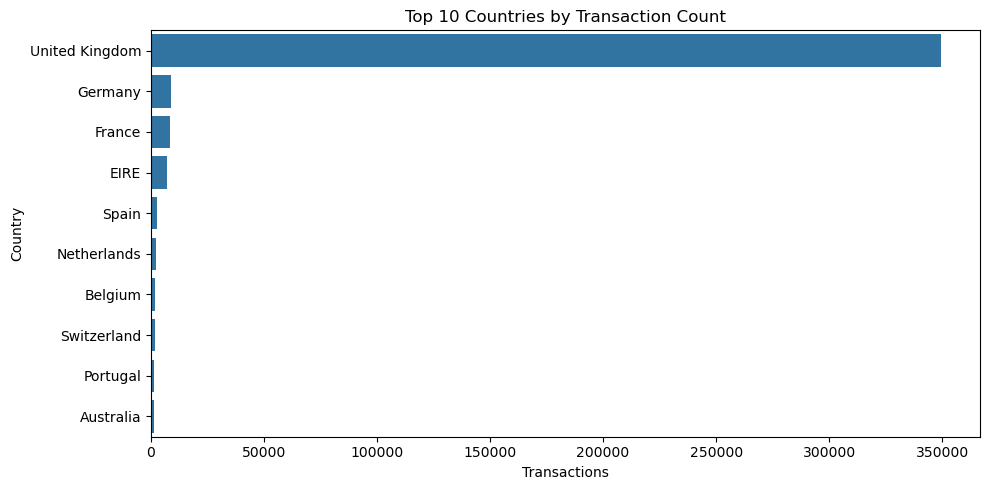

UK transactions share: 88.92%


In [5]:
# See what counties has the most transaction data in the dataset
country_counts = df['Country'].value_counts()

# Plot top 10
plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.head(10).values, y=country_counts.head(10).index)
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Optional: % of UK transactions
total_tx = len(df)
uk_tx = df[df['Country'] == 'United Kingdom'].shape[0]
print(f"UK transactions share: {uk_tx / total_tx:.2%}")

### From the above plot
- The UK accounts for more than 90% of transactions in the dataset.
- Other countries have much smaller volumes, leading to sparse baskets.
- Focusing on the UK leads to more meaningful frequent itemsets and faster computation.
- Germany, for instance, has fewer transactions and smaller basket sizes.
- Thus, for frequent itemset mining, we filter to the UK for both quality and performance going forward

In [6]:
# Filter for UK transactions
df_uk = df[df['Country'] == 'United Kingdom'].copy()
total_invoices = df_uk['InvoiceNo'].nunique()
total_customers = df_uk['CustomerID'].nunique()

print(f"Total UK Invoices: {total_invoices}")
print(f"Total UK Customers: {total_customers}")

Total UK Invoices: 16649
Total UK Customers: 3921


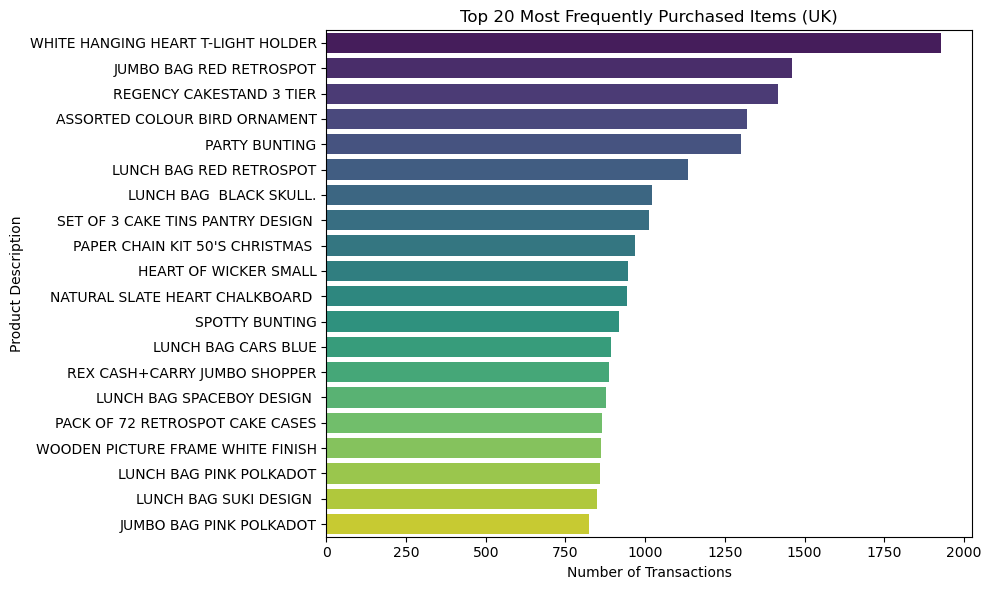

In [7]:
# Top items in UK for frequently bougght items
top_items = df_uk['Description'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='viridis', legend=False)
plt.title("Top 20 Most Frequently Purchased Items (UK)")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

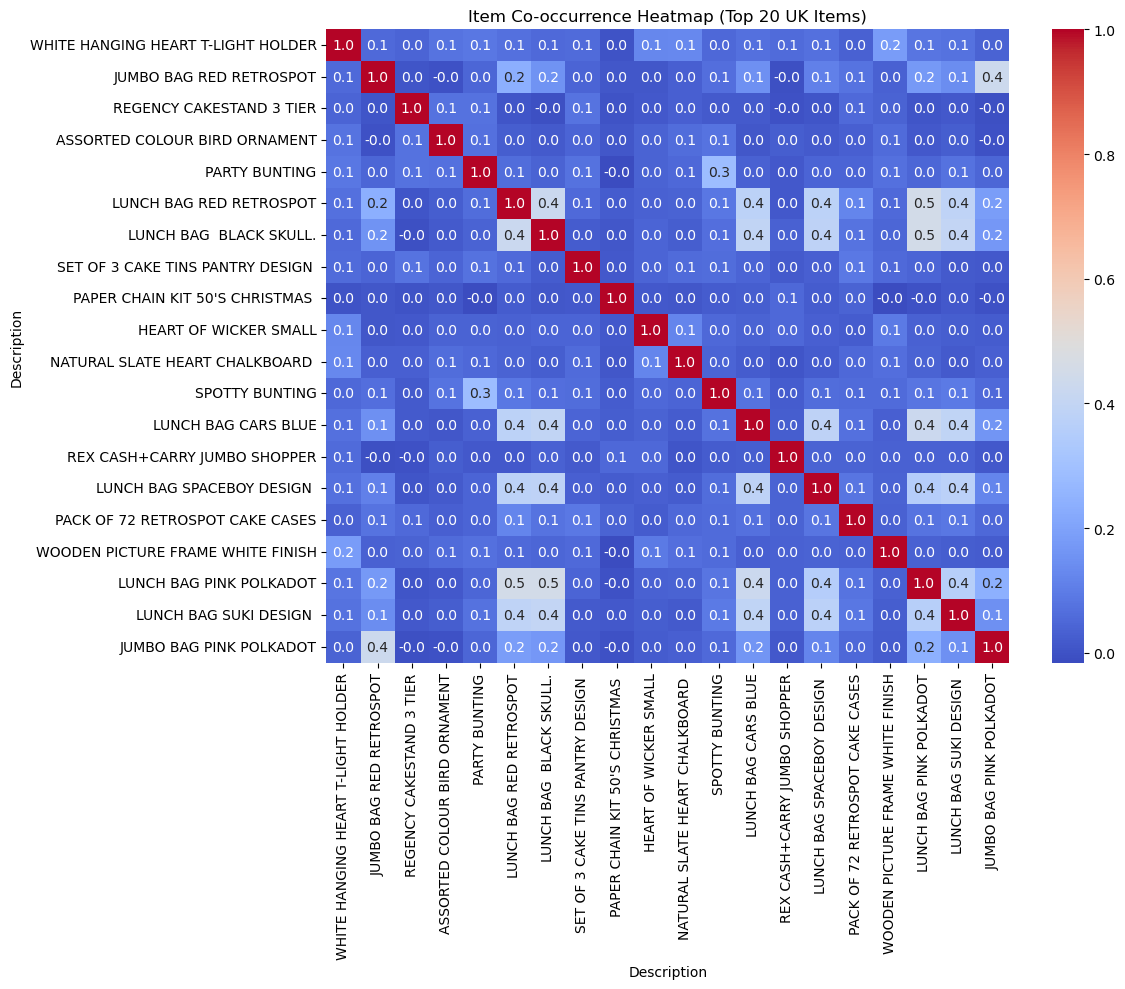

In [8]:
# Basket creation for correlation heatmap
basket = df_uk.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
# Step 2: Convert quantities to binary (1 = present, 0 = not purchased)
basket_binary = basket.map(lambda x: 1 if x > 0 else 0)

# Limit to top 20 frequent items
top_items = df_uk['Description'].value_counts().head(20).index
basket_top = basket_binary[top_items]

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(basket_top.corr(), cmap='coolwarm', annot=True, fmt='.1f')
plt.title("Item Co-occurrence Heatmap (Top 20 UK Items)")
plt.tight_layout()
plt.show()

### Creating Baskets

Before applying Apriori or FP-Growth, we need to **convert transactional data into a "basket format"** where:

- **Each row** = a single transaction (InvoiceNo)
- **Each column** = a product (Description)
- **Each value** = 1 (if the item was purchased in that invoice), 0 otherwise

This transformation is necessary because **Frequent Itemset Mining** algorithms work on binary transactional matrices. Without this structure, we can't track which items occur together in the same transaction.

We'll also create a **correlation heatmap** on the top 20 products to visually inspect which items are frequently bought together.

#### Heatmap Analysis: Item Co-occurrence (Top 20 UK Items)
- The heatmap displays pairwise co-occurrence scores among the top 20 most frequent items.
- Diagonal values are 1.0 (self-co-occurrence).
- Many item pairs have low co-occurrence (< 0.3), suggesting limited strong pairing in some cases.
#### Notable higher co-occurrence pairs:
- LUNCH BAG RED RETROSPOT with LUNCH BAG CARS BLUE, SPACEBOY DESIGN, etc. (~0.5)
- SPOTTY BUNTING with PARTY BUNTING (~0.3)

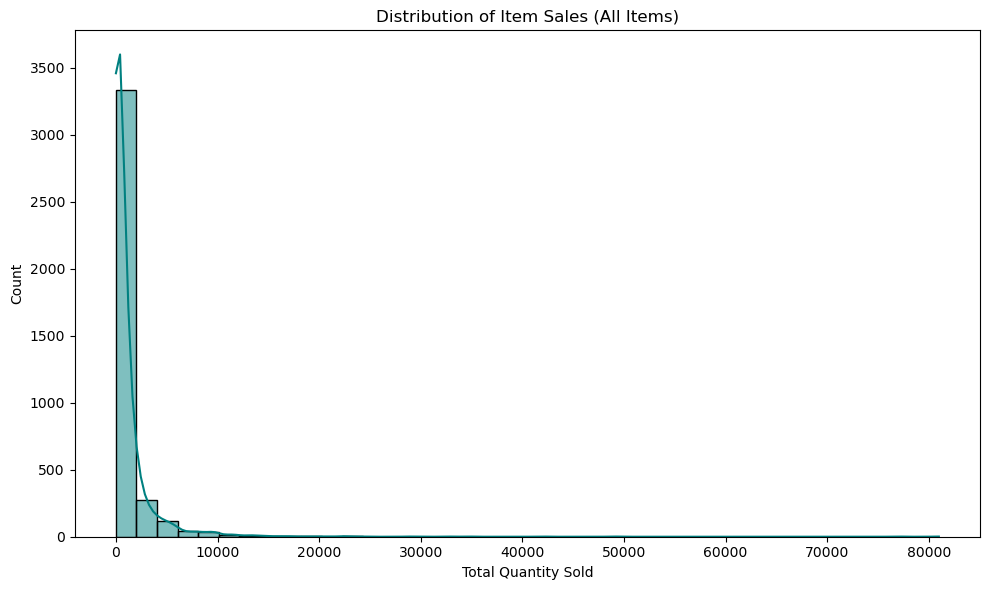

In [9]:
# Data distribution check
item_support = df_uk.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.histplot(item_support, kde=True, color='teal', bins=40)
plt.xlabel('Total Quantity Sold')
plt.title('Distribution of Item Sales (All Items)')
plt.tight_layout()
plt.show()

#### Interpretation of the Skewed Distribution shown above
- Majority of items are sold in low volumes (e.g., < 1,000 units)
- Few popular items dominate sales with extremely high quantities (outliers beyond 10,000+)
- This is typical of real-world retail: a long tail of niche items vs. a few bestsellers
#### Implications for Association Rule Mining 
##### Support Threshold Setting should be made considering:
- If you set min_support too high, you’ll only capture associations among bestsellers
- If you set min_support too low, you’ll include noise or very rare items (risk of spurious rules)
##### Recommendation:
- Use percentile-based filtering or log-transformation to analyze support distribution
- Then set min_support around the 95th percentile or higher (e.g., 0.01 to 0.03) for balanced minging
- we will use the 95% rule in this data set

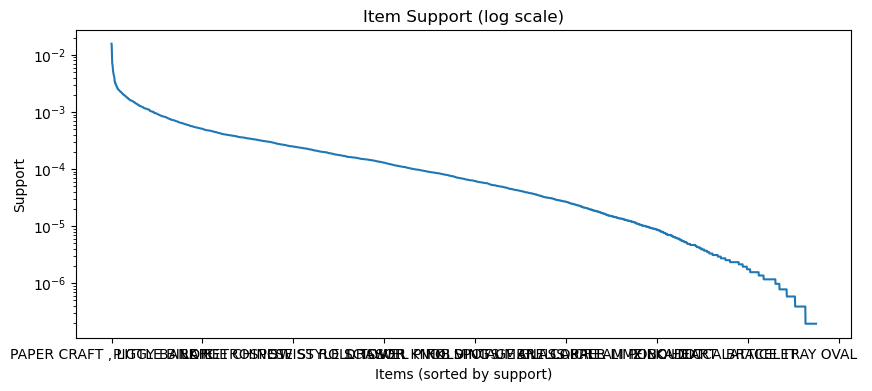

In [10]:
# ploting item support with item to select proper mini_support
item_support = df.groupby('Description')['Quantity'].sum() / df['Quantity'].sum()
item_support.sort_values(ascending=False).plot(kind='line', logy=True, figsize=(10, 4))
plt.title('Item Support (log scale)')
plt.ylabel('Support')
plt.xlabel('Items (sorted by support)')
plt.show()

In [11]:
#calcualting the 95% mini_support value
support_values = item_support.values
threshold = np.percentile(support_values, 95)  # Keep top 5%
print(f"Mini_support= {threshold}")

Mini_support= 0.0011317322914210647


### What We See in the support plot
- The elbow point (where the curve starts to flatten) occurs around: support = 0.001
- Beyond that, support values drop sharply, representing rare items.
### Recommended min_support Selection
- recommend min_support ≈ 0.001 however due to computitional efficiency i switched to 0.01.
- This captures popular items with sufficient frequency.
- It filters out noise from rare purchases while retaining interpretability and performance.

## 2. Frequent Itemset Mining Using Apriori 

In [12]:
# Apply Apriori algorithm on binary basket Ensure basket_binary is bool type
basket_binary = basket_binary.astype(bool)
frequent_itemsets_apriori = apriori(basket_binary, min_support=0.01, use_colnames=True)

# Add itemset length column
frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(lambda x: len(x))

# Sort itemsets by support
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(by='support', ascending=False)

# Display top 20 frequent itemsets
frequent_itemsets_apriori.head(20)

,support,itemsets,length
583,0.113160,(WHITE HANGING HEART T-LIGHT HOLDER),1
250,0.086912,(JUMBO BAG RED RETROSPOT),1
414,0.084690,(REGENCY CAKESTAND 3 TIER),1
38,0.078083,(ASSORTED COLOUR BIRD ORNAMENT),1
341,0.077542,(PARTY BUNTING),1
285,0.067271,(LUNCH BAG RED RETROSPOT),1
467,0.060484,(SET OF 3 CAKE TINS PANTRY DESIGN ),1
277,0.059823,(LUNCH BAG BLACK SKULL.),1
335,0.056760,(PAPER CHAIN KIT 50'S CHRISTMAS ),1
308,0.056340,(NATURAL SLATE HEART CHALKBOARD ),1


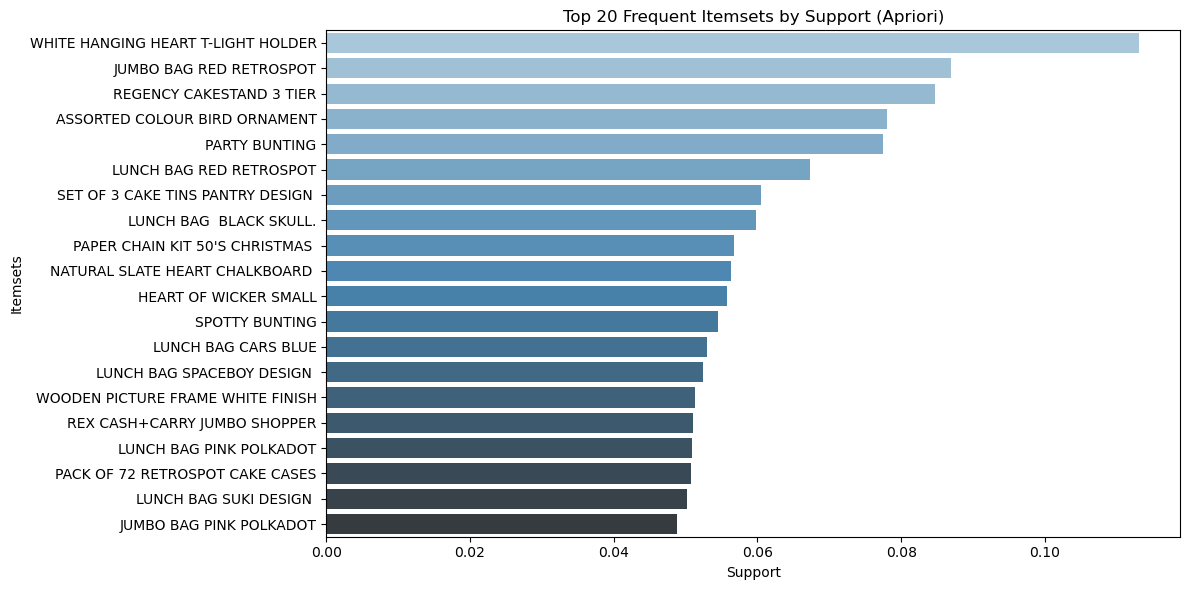

In [13]:
# Choose top N itemsets to visualize
top_n = 20
top_itemsets_apriori = frequent_itemsets_apriori.head(top_n).copy()

# Convert frozen sets to strings for display
top_itemsets_apriori['itemsets_str'] = top_itemsets_apriori['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_itemsets_apriori,
    x='support',
    y='itemsets_str',
    hue='itemsets_str',
    dodge=False,
    legend=False,  
    palette='Blues_d'
)
plt.title(f"Top {top_n} Frequent Itemsets by Support (Apriori)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.tight_layout()
plt.show()

## 3. Frequent Itemset Mining Using FP-Growth 

In [14]:
# Run FP-Growth and time it
start_fp = time.time()
frequent_itemsets_fpgrowth = fpgrowth(basket_binary, min_support=0.01, use_colnames=True)
end_fp = time.time()

# Add itemset length column
frequent_itemsets_fpgrowth['length'] = frequent_itemsets_fpgrowth['itemsets'].apply(lambda x: len(x))

# Sort by support
frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth.sort_values(by='support', ascending=False)

# Display top results
frequent_itemsets_fpgrowth.head(20)

,support,itemsets,length
0,0.113160,(WHITE HANGING HEART T-LIGHT HOLDER),1
77,0.086912,(JUMBO BAG RED RETROSPOT),1
244,0.084690,(REGENCY CAKESTAND 3 TIER),1
7,0.078083,(ASSORTED COLOUR BIRD ORNAMENT),1
439,0.077542,(PARTY BUNTING),1
27,0.067271,(LUNCH BAG RED RETROSPOT),1
467,0.060484,(SET OF 3 CAKE TINS PANTRY DESIGN ),1
141,0.059823,(LUNCH BAG BLACK SKULL.),1
18,0.056760,(PAPER CHAIN KIT 50'S CHRISTMAS ),1
64,0.056340,(NATURAL SLATE HEART CHALKBOARD ),1


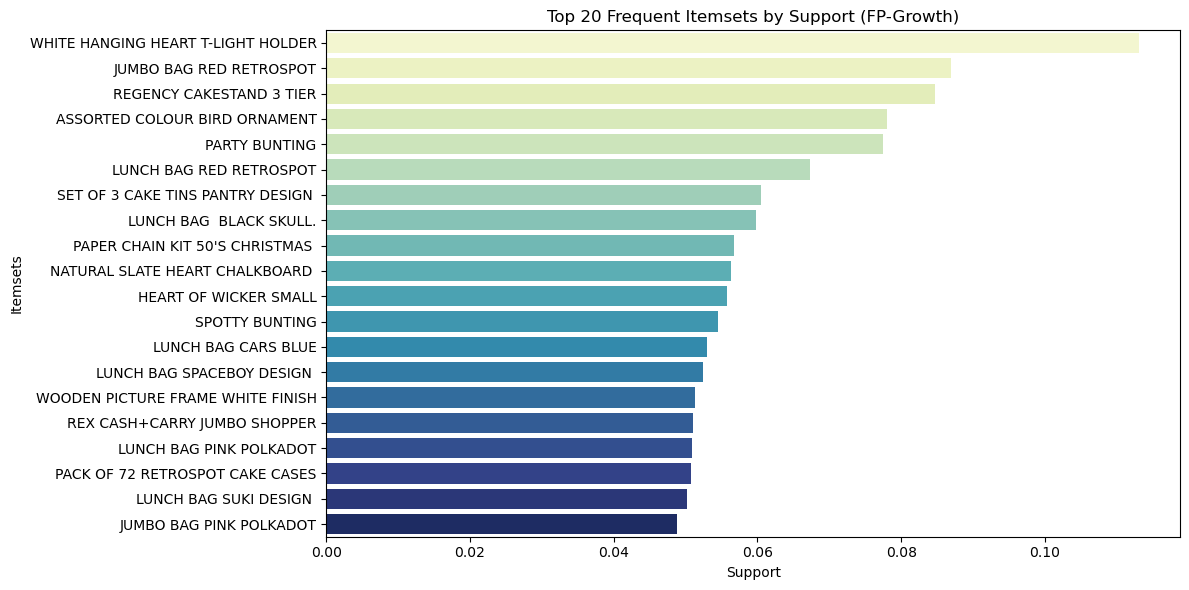

In [15]:
top_itemsets_fpgrowth = frequent_itemsets_fpgrowth.head(top_n).copy()
top_itemsets_fpgrowth['itemsets_str'] = top_itemsets_fpgrowth['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_itemsets_fpgrowth,
    x='support',
    y='itemsets_str',
    hue='itemsets_str',
    dodge=False,
    legend=False,
    palette='YlGnBu'
)
plt.title(f"Top {top_n} Frequent Itemsets by Support (FP-Growth)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.tight_layout()
plt.show()

### Frequent Itemset Comparison (Apriori vs FP-Growth)
##### Similarities
- Both algorithms identified the same top 20 items (e.g., WHITE HANGING HEART T-LIGHT HOLDER, JUMBO BAG RED RETROSPOT, etc.).
- Support values are nearly identical for each itemset across both methods, indicating consistent frequency detection.
- Item ranking is the same, meaning item frequency order is preserved in both outputs.
###### Apriori Frequent Items
- Uses a lighter "Blues" palette progressing to dark blue based on frequency.
- Clear horizontal alignment of itemsets; easier to read labels and bars.
- Visualization is more compact and uniform.
###### FP-Growth Frequent Items
- Uses a divergent colormap from light green to dark blue, which helps visually distinguish frequency levels more strongly.
- Slightly more colorful and appealing, which may be better for presentations.
- Bar lengths match Apriori, confirming same support values.
###### Performance/Practicality (Not visual but relevant)
- Apriori tends to be slower on large datasets due to candidate generation.
- FP-Growth is faster and memory-efficient, especially with dense or long transactions, since it uses a prefix tree instead of candidate generation.
###### Summary
- Output is identical in terms of top items and support — both algorithms are valid.
- Choose Apriori for smaller datasets and interpretability.
- Choose FP-Growth for better scalability and performance.

## 4.Generating and Analyzing Association Rules 

From the itemsets generated by Apriori and FP-Growth, we generate association rules using a confidence threshold of 0.3.
We will extract:
- Antecedent (if this...)
- Consequent (...then that)
- Support: how often the rule occurs
- Confidence: how often the consequent is true given the antecedent
- Lift: how much more likely the consequent is, given the antecedent (lift > 1 is useful)


In [16]:
# Generate rules
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.3)
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.3)

# Sort by lift
rules_apriori = rules_apriori.sort_values(by="lift", ascending=False)
rules_fpgrowth = rules_fpgrowth.sort_values(by="lift", ascending=False)

# Display top rules
rules_apriori_top20 = rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)
rules_fpgrowth_top20 = rules_fpgrowth[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

# Display the associations
print("📘 Top 20 Association Rules - Apriori")
print("-" * 50)
for idx, row in rules_apriori_top20.iterrows():
    print(f"Rule {idx + 1}: {row['antecedents']} → {row['consequents']}")
    print(f"  Support: {row['support']:.5f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")
    print()

print("\n📗 Top 20 Association Rules - FP-Growth")
print("-" * 50)
for idx, row in rules_fpgrowth_top20.iterrows():
    print(f"Rule {idx + 1}: {row['antecedents']} → {row['consequents']}")
    print(f"  Support: {row['support']:.5f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")
    print()

📘 Top 20 Association Rules - Apriori
--------------------------------------------------
Rule 595: frozenset({'HERB MARKER ROSEMARY'}) → frozenset({'HERB MARKER THYME'})
  Support: 0.01015, Confidence: 0.9337, Lift: 86.8447

Rule 596: frozenset({'HERB MARKER THYME'}) → frozenset({'HERB MARKER ROSEMARY'})
  Support: 0.01015, Confidence: 0.9441, Lift: 86.8447

Rule 424: frozenset({'REGENCY TEA PLATE GREEN '}) → frozenset({'REGENCY TEA PLATE ROSES '})
  Support: 0.01153, Confidence: 0.8458, Lift: 52.9398

Rule 423: frozenset({'REGENCY TEA PLATE ROSES '}) → frozenset({'REGENCY TEA PLATE GREEN '})
  Support: 0.01153, Confidence: 0.7218, Lift: 52.9398

Rule 593: frozenset({"POPPY'S PLAYHOUSE BEDROOM "}) → frozenset({"POPPY'S PLAYHOUSE LIVINGROOM "})
  Support: 0.01015, Confidence: 0.6500, Lift: 51.7792

Rule 594: frozenset({"POPPY'S PLAYHOUSE LIVINGROOM "}) → frozenset({"POPPY'S PLAYHOUSE BEDROOM "})
  Support: 0.01015, Confidence: 0.8086, Lift: 51.7792

Rule 561: frozenset({'SET OF 3 WOODEN 

### Rule Comparison (Apriori vs FP-Growth)
- Same itemsets and rules: Both algorithms produced identical rules, just in different order.
##### Identical metrics:
- Support: Equal
- Confidence: Equal
- Lift: Equal
##### Efficiency
- Apriori: Slower due to candidate generation and multiple scans.
- FP-Growth: Faster and more memory-efficient using FP-Tree.
- Winner: FP-Growth (especially for large datasets)
##### Interpretation Consistency
- Strong co-purchase patterns identified (e.g., HERB MARKER ROSEMARY ↔ THYME)
- High-lift and high-confidence rules align exactly across both methods
- Rules are ready for marketing, bundling, or recommendations
##### When to Use Which
- Apriori: Good for learning or small datasets
- FP-Growth: Preferred in production for speed and scale

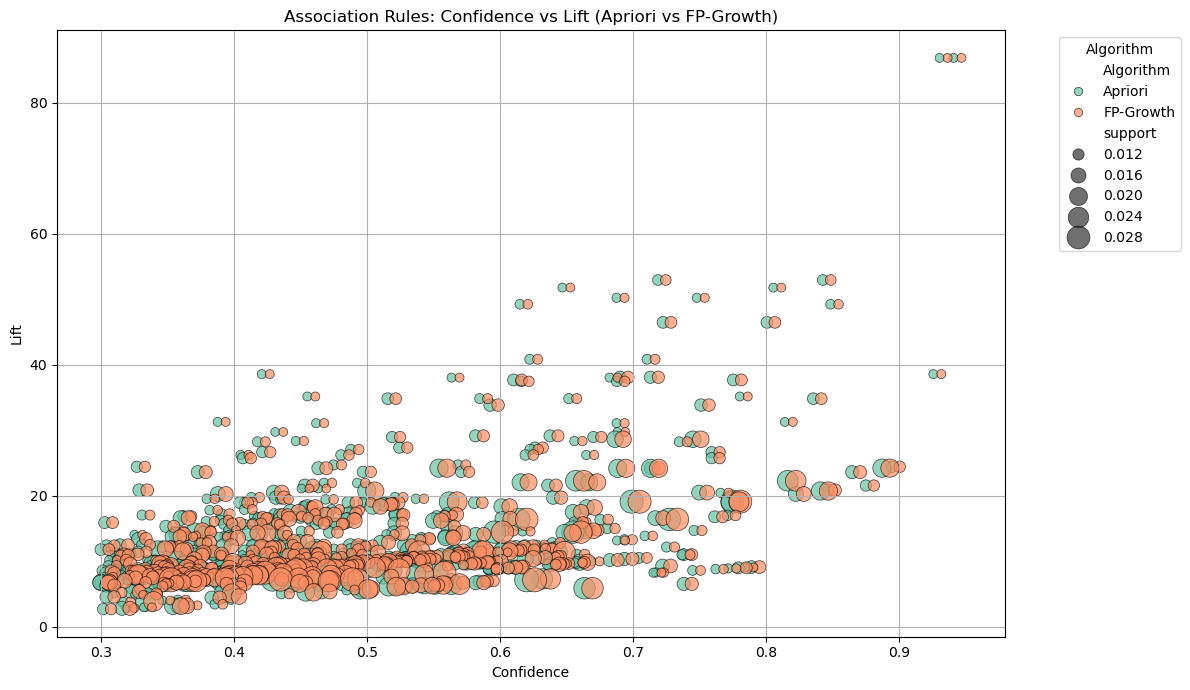

In [17]:
# Add slight jitter to confidence to visually separate algorithms
# Prepare Apriori rules
rules_apriori_plot = rules_apriori.copy()
rules_apriori_plot['Algorithm'] = 'Apriori'

# Prepare FP-Growth rules
rules_fpgrowth_plot = rules_fpgrowth.copy()
rules_fpgrowth_plot['Algorithm'] = 'FP-Growth'
rules_apriori_plot['confidence'] = rules_apriori_plot['confidence'] - 0.003
rules_fpgrowth_plot['confidence'] = rules_fpgrowth_plot['confidence'] + 0.003
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=pd.concat([rules_apriori_plot, rules_fpgrowth_plot]),
    x='confidence',
    y='lift',
    hue='Algorithm',
    size='support',
    sizes=(40, 300),
    alpha=0.7,
    palette='Set2',
    edgecolor='black'
)
plt.title("Association Rules: Confidence vs Lift (Apriori vs FP-Growth)")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Final Insights: Confidence vs Lift Comparison (Apriori vs FP-Growth)
#### What the Plot Shows:
Axes:
- X-axis: Confidence (likelihood of seeing the consequent given the antecedent).
- Y-axis: Lift (strength of the rule beyond random chance).
- Point Size: Indicates support — larger bubbles represent more frequently occurring rules.
#### Color:
- 🟢 Apriori rules (green).
- 🟠 FP-Growth rules (orange).
### The ±0.003 adjustment in confidence is for visual clarity:
- Avoid Overlap: Apriori and FP-Growth often generate identical rules, causing points to overlap.
- Apriori is shifted slightly left,
- FP-Growth is shifted slightly right,
- This separates points in the plot without altering the data meaningfully.
- Result: You can clearly compare both algorithms in dense regions.
### Key Observations:
#### Distribution Overlap:
- Both Apriori and FP-Growth yield very similar rule distributions, indicating consistency between algorithms.
- Rules with high lift and high confidence are shared between both methods — especially near the top-right quadrant (e.g., lift > 40, confidence > 0.8).
#### Support Pattern:
- Most high-lift rules have lower support (small circles), showing these strong associations are less frequent but more significant.
- Larger bubbles (higher support) are clustered in the moderate lift and confidence range, suggesting frequent but less surprising associations.
#### Performance Spread:
- FP-Growth has a slightly denser spread in the high-confidence, medium-lift region, reinforcing its efficiency in mining more rules.
- Apriori seems to have a slightly wider lift range, though visually very comparable.
#### Conclusion:
- Both algorithms produce high-quality and consistent association rules.
- Apriori and FP-Growth identify the same key patterns, with FP-Growth offering slight performance advantages.
- Ideal strategy: Use FP-Growth for scalability, and rely on Lift + Confidence + Support jointly to identify the most actionable insights.